<a href="https://colab.research.google.com/github/Gabriel-idkw/Customer-Behavior-Prediction/blob/main/01_data_preprocessing_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Data Preprocessing, EDA & Feature Engineering



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)


## Step 1.1: Data Hygiene & Exploratory Analysis (EDA)
### Load Raw Data

In [4]:
df = pd.read_csv('/content/raw_ecommerce_data.csv', parse_dates=['Purchase Date'])
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Shape: 250,000 rows x 13 columns


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Customer ID            250000 non-null  int64         
 1   Purchase Date          250000 non-null  datetime64[ns]
 2   Product Category       250000 non-null  object        
 3   Product Price          250000 non-null  int64         
 4   Quantity               250000 non-null  int64         
 5   Total Purchase Amount  250000 non-null  int64         
 6   Payment Method         250000 non-null  object        
 7   Customer Age           250000 non-null  int64         
 8   Returns                202618 non-null  float64       
 9   Customer Name          250000 non-null  object        
 10  Age                    250000 non-null  int64         
 11  Gender                 250000 non-null  object        
 12  Churn                  250000 non-null  int6

In [6]:
df.describe(include='all').T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Customer ID,250000.0,NaN,NaN,NaN,25017.632092,1.0,12590.0,25011.0,37441.25,50000.0,14412.515718
Purchase Date,250000,NaN,NaN,NaN,2021-11-06 19:26:22.286192384,2020-01-01 00:07:26,2020-12-03 08:10:12,2021-11-06 07:39:08.500000,2022-10-11 01:21:56.249999872,2023-09-13 18:42:49,NaN
Product Category,250000,4,Electronics,62630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product Price,250000.0,NaN,NaN,NaN,254.742724,10.0,132.0,255.0,377.0,500.0,141.738104
Quantity,250000.0,NaN,NaN,NaN,3.004936,1.0,2.0,3.0,4.0,5.0,1.414737
Total Purchase Amount,250000.0,NaN,NaN,NaN,2725.385196,100.0,1476.0,2725.0,3975.0,5350.0,1442.576095
Payment Method,250000,3,Credit Card,83547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Age,250000.0,NaN,NaN,NaN,43.798276,18.0,30.0,44.0,57.0,70.0,15.364915
Returns,202618.0,NaN,NaN,NaN,0.500824,0.0,0.0,1.0,1.0,1.0,0.500001
Customer Name,250000,39878,Michael Johnson,119,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Handle Missing Values
Check for nulls across numeric and categorical columns.

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report[missing_report['missing_count'] > 0]


,missing_count,missing_pct
Returns,47382,18.95


In [8]:
print("Returns value counts before imputation:")
print(df['Returns'].value_counts(dropna=False))

df['Returns'] = df['Returns'].fillna(0).astype(int)

numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['object', 'string']).columns

for col in numeric_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print("\nRemaining nulls after imputation:", df.isnull().sum().sum())


Returns value counts before imputation:
Returns
1.0    101476
0.0    101142
NaN     47382
Name: count, dtype: int64

Remaining nulls after imputation: 0


### Remove Anomalies
Strip duplicate transactions, negative quantities, and invalid price entries.

In [9]:
print("Exact duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

before = len(df)
df = df[(df['Quantity'] > 0) & (df['Product Price'] > 0) & (df['Total Purchase Amount'] > 0)]
print(f"Rows removed for non-positive quantity/price/amount: {before - len(df)}")

implied = df['Product Price'] * df['Quantity']
consistent_pct = (np.isclose(implied, df['Total Purchase Amount'], rtol=0.5)).mean() * 100
print(f"Rows where Total Purchase Amount is within 50% of Price*Quantity: {consistent_pct:.1f}%")

print(f"Final row count after anomaly removal: {len(df):,}")


Exact duplicate rows: 0
Rows removed for non-positive quantity/price/amount: 0
Rows where Total Purchase Amount is within 50% of Price*Quantity: 19.9%
Final row count after anomaly removal: 250,000


In [10]:
# Duplicate customer metadata check: Age and Customer Age are redundant (verify),
# drop the duplicate column to avoid double-weighting the same signal downstream.
print("Age == Customer Age for all rows:", (df['Age'] == df['Customer Age']).all())
df = df.drop(columns=['Age'])


Age == Customer Age for all rows: True


### Distribution Inspection
Histograms for the core numerical variables to inspect skew before any transformation.

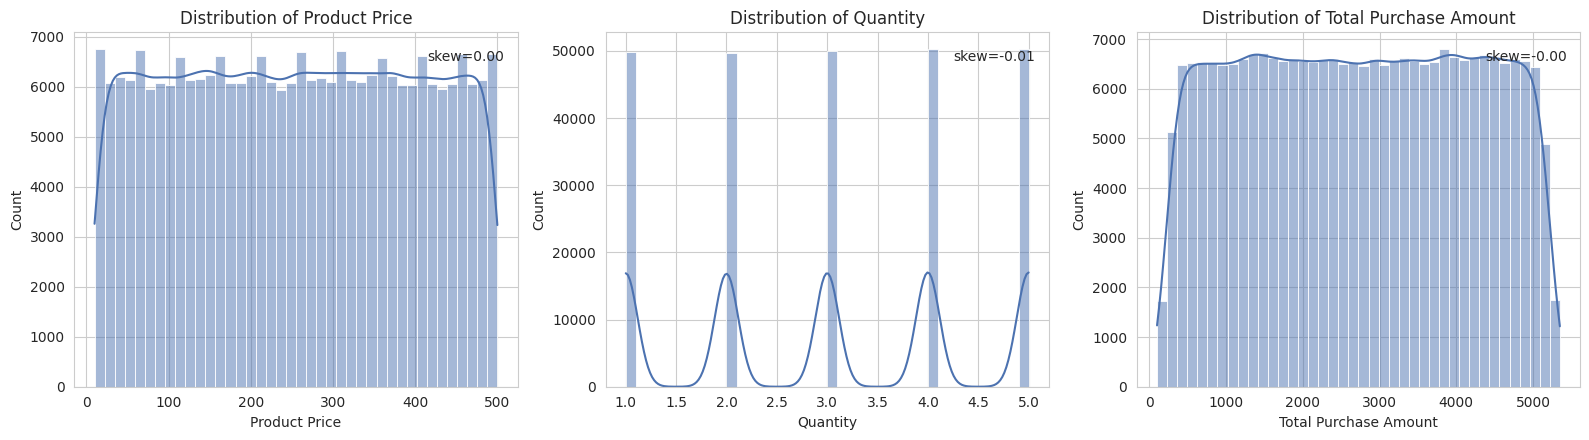

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ['Product Price', 'Quantity', 'Total Purchase Amount']):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f'Distribution of {col}')
    skew = df[col].skew()
    ax.text(0.97, 0.95, f'skew={skew:.2f}', transform=ax.transAxes, ha='right', va='top')
plt.tight_layout()
plt.savefig('/content/data/eda_distributions.png', dpi=110)
plt.show()


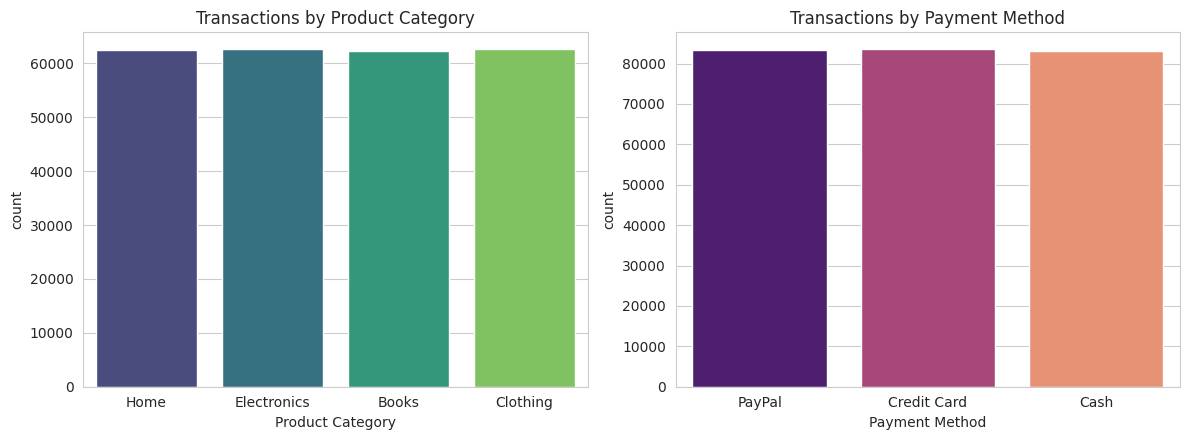

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(data=df, x='Product Category', ax=axes[0], palette='viridis')
axes[0].set_title('Transactions by Product Category')
sns.countplot(data=df, x='Payment Method', ax=axes[1], palette='magma')
axes[1].set_title('Transactions by Payment Method')
plt.tight_layout()
plt.savefig('data/eda_categoricals.png', dpi=110)
plt.show()


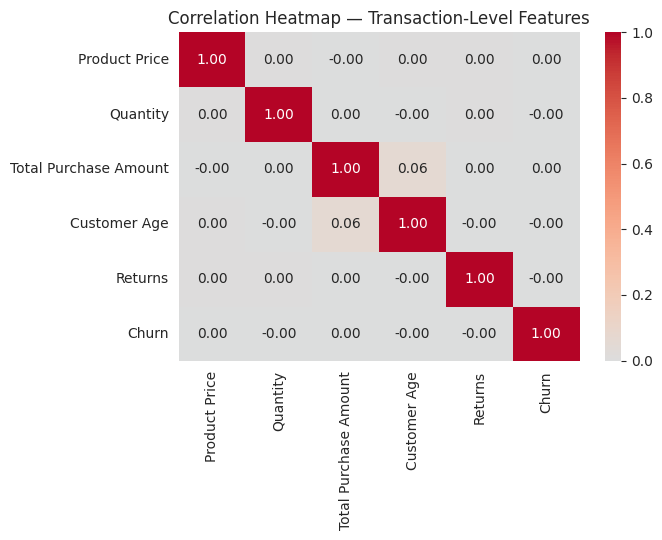

In [13]:
corr_cols = ['Product Price', 'Quantity', 'Total Purchase Amount', 'Customer Age', 'Returns', 'Churn']
plt.figure(figsize=(7, 5.5))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Transaction-Level Features')
plt.tight_layout()
plt.savefig('/content/data/eda_correlation.png', dpi=110)
plt.show()


## Step 1.2: RFM & Behavioral Feature Aggregation

In [14]:
snapshot_date = df['Purchase Date'].max() + pd.Timedelta(days=1)
print("Snapshot date (latest transaction + 1 day):", snapshot_date.date())

customer_meta = (
    df.sort_values('Purchase Date')
      .groupby('Customer ID')
      .agg(Customer_Name=('Customer Name', 'last'),
           Gender=('Gender', 'last'),
           Customer_Age=('Customer Age', 'last'))
)

rfm = df.groupby('Customer ID').agg(
    Recency=('Purchase Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Purchase Date', 'count'),
    Monetary=('Total Purchase Amount', 'sum'),
    Returned_Orders=('Returns', 'sum'),
    Total_Orders=('Returns', 'count'),
)

rfm['AOV'] = rfm['Monetary'] / rfm['Frequency']
rfm['Return_Rate_Pct'] = (rfm['Returned_Orders'] / rfm['Total_Orders']) * 100

rfm = rfm.join(customer_meta)
rfm = rfm.drop(columns=['Returned_Orders', 'Total_Orders'])
rfm = rfm.reset_index()

print(f"Customer-level matrix: {rfm.shape[0]:,} customers x {rfm.shape[1]} features")
rfm.head()


Snapshot date (latest transaction + 1 day): 2023-09-14
Customer-level matrix: 49,661 customers x 9 features


,Customer ID,Recency,Frequency,Monetary,AOV,Return_Rate_Pct,Customer_Name,Gender,Customer_Age
0,1,289,3,6290,2096.666667,0.000000,Dominic Cline,Female,67
1,2,73,6,16481,2746.833333,66.666667,Crystal Day,Female,42
2,3,223,4,9423,2355.750000,0.000000,Joseph Perez,Male,31
3,4,442,5,7826,1565.200000,60.000000,Wyatt Love,Male,37
4,5,425,5,9769,1953.800000,60.000000,Shannon Hoffman,Female,24


In [15]:
rfm[['Recency', 'Frequency', 'Monetary', 'AOV', 'Return_Rate_Pct']].describe().T


,count,mean,std,min,25%,50%,75%,max
Recency,49661.0,262.335374,246.804539,1.0,78.0,187.0,371.000000,1352.0
Frequency,49661.0,5.034131,2.199399,1.0,3.0,5.0,6.000000,17.0
Monetary,49661.0,13719.947222,6811.065854,125.0,8718.0,13008.0,17921.000000,50659.0
AOV,49661.0,2727.091903,733.460529,125.0,2258.0,2729.0,3196.333333,5296.0
Return_Rate_Pct,49661.0,40.612600,24.796333,0.0,25.0,40.0,55.555556,100.0


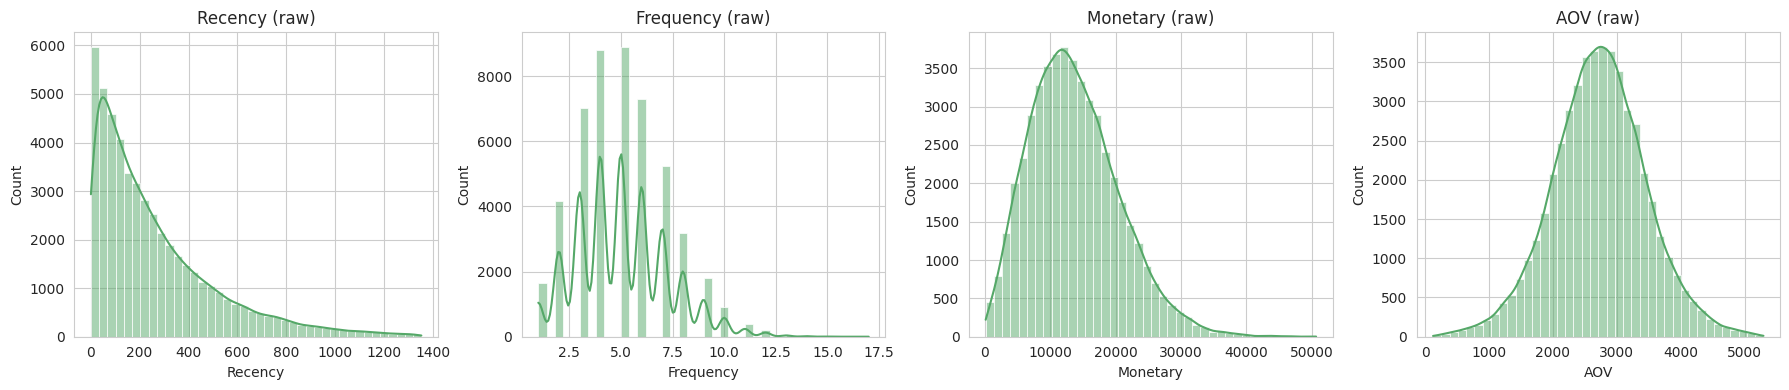

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary', 'AOV']):
    sns.histplot(rfm[col], bins=40, kde=True, ax=ax, color='#55A868')
    ax.set_title(f'{col} (raw)')
plt.tight_layout()
plt.savefig('/content/data/eda_rfm_raw.png', dpi=110)
plt.show()


## Step 1.3: Normalization & Feature Scaling

In [17]:
# 1. Log transformation on right-skewed count/monetary features
for col in ['Frequency', 'Monetary']:
    print(f"{col} skew before log: {rfm[col].skew():.2f}")
    rfm[f'{col}_log'] = np.log1p(rfm[col])
    print(f"{col} skew after log:  {rfm[f'{col}_log'].skew():.2f}")


Frequency skew before log: 0.51
Frequency skew after log:  -0.51
Monetary skew before log: 0.62
Monetary skew after log:  -1.36


In [18]:
# 2. IQR outlier capping applied to every feature that will feed the clustering models
clustering_features = ['Recency', 'Frequency_log', 'Monetary_log', 'AOV', 'Return_Rate_Pct']

def cap_iqr(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return series.clip(lower, upper), (series < lower).sum() + (series > upper).sum()

for col in clustering_features:
    rfm[col], n_capped = cap_iqr(rfm[col])
    print(f"{col}: capped {n_capped} outlier values ({n_capped/len(rfm)*100:.2f}%)")


Recency: capped 2157 outlier values (4.34%)
Frequency_log: capped 3 outlier values (0.01%)
Monetary_log: capped 1525 outlier values (3.07%)
AOV: capped 819 outlier values (1.65%)
Return_Rate_Pct: capped 0 outlier values (0.00%)


In [19]:
# 3. Standard scaling — mean 0, std 1 — on the final clustering feature set
scaler = StandardScaler()
scaled_values = scaler.fit_transform(rfm[clustering_features])
scaled_cols = [f'{c}_scaled' for c in clustering_features]
rfm[scaled_cols] = scaled_values

print("Post-scaling sanity check (mean ~0, std ~1):")
rfm[scaled_cols].agg(['mean', 'std']).round(3)


Post-scaling sanity check (mean ~0, std ~1):


,Recency_scaled,Frequency_log_scaled,Monetary_log_scaled,AOV_scaled,Return_Rate_Pct_scaled
mean,0.0,0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0


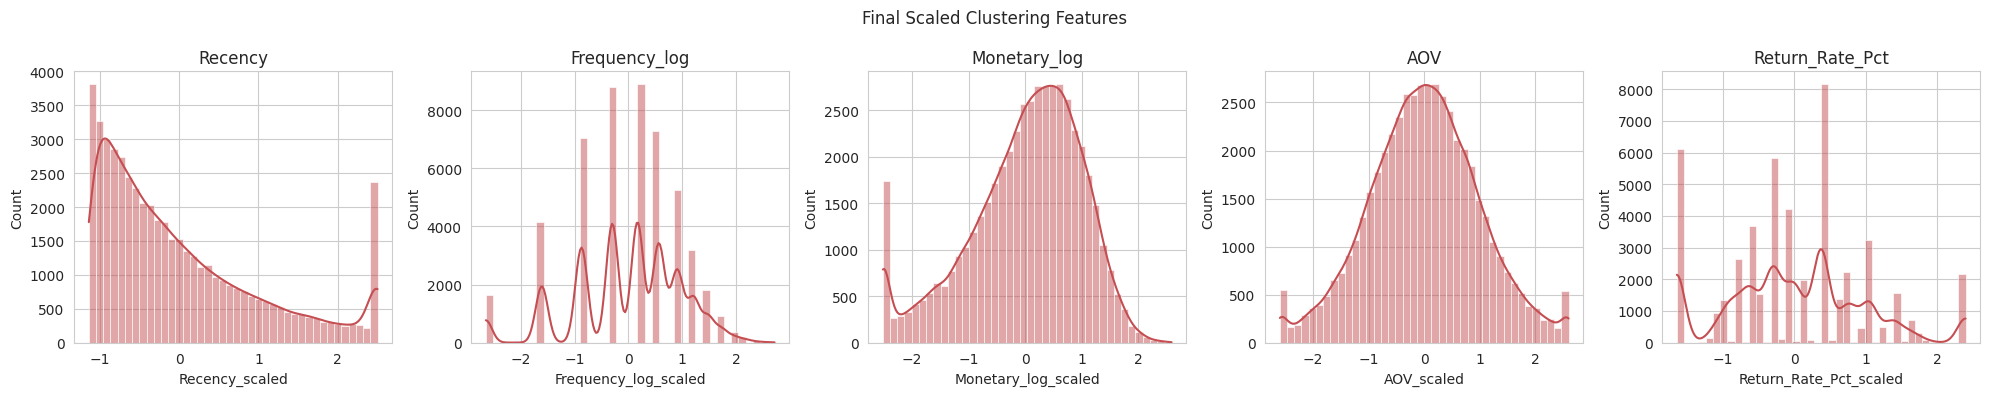

In [20]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, scaled_cols):
    sns.histplot(rfm[col], bins=40, kde=True, ax=ax, color='#C44E52')
    ax.set_title(col.replace('_scaled', ''))
plt.suptitle('Final Scaled Clustering Features')
plt.tight_layout()
plt.savefig('/content/data/eda_rfm_scaled.png', dpi=110)
plt.show()


### Export Dataset


In [23]:
import joblib

export_cols = ['Customer ID', 'Customer_Name', 'Gender', 'Customer_Age',
               'Recency', 'Frequency', 'Monetary', 'AOV', 'Return_Rate_Pct'] + scaled_cols
final_df = rfm[export_cols].rename(columns={'Customer_Name': 'Customer Name', 'Customer_Age': 'Customer Age'})

final_df.to_csv('/content/data/preprocessed_rfm_scaled.csv', index=False)
joblib.dump(scaler, '/content/model/rfm_scaler.pkl')
joblib.dump(clustering_features, '/content/model/rfm_scaler_feature_order.pkl')

print(f"Exported /content/data/preprocessed_rfm_scaled.csv -> {final_df.shape[0]:,} rows x {final_df.shape[1]} columns")
final_df.head()


Exported /content/data/preprocessed_rfm_scaled.csv -> 49,661 rows x 14 columns


,Customer ID,Customer Name,Gender,Customer Age,Recency,Frequency,Monetary,AOV,Return_Rate_Pct,Recency_scaled,Frequency_log_scaled,Monetary_log_scaled,AOV_scaled,Return_Rate_Pct_scaled
0,1,Dominic Cline,Female,67,289.0,3,6290,2096.666667,0.000000,0.156491,-0.872192,-1.159721,-0.873317,-1.637864
1,2,Crystal Day,Female,42,73.0,6,16481,2746.833333,66.666667,-0.814439,0.563286,0.571692,0.027255,1.050733
2,3,Joseph Perez,Male,31,223.0,4,9423,2355.750000,0.000000,-0.140182,-0.299803,-0.433216,-0.514450,-1.637864
3,4,Wyatt Love,Male,37,442.0,5,7826,1565.200000,60.000000,0.844233,0.167872,-0.767006,-1.609472,0.781873
4,5,Shannon Hoffman,Female,24,425.0,5,9769,1953.800000,60.000000,0.767817,0.167872,-0.368398,-1.071207,0.781873
